# Heart Disease Classification — SVC + XGBoost Stacking Ensemble (v2)
**Both base learners Optuna-tuned · XGBoost meta-learner · passthrough=True · threshold optimisation**

```
Raw Features
     │
     ├──► SVC (RBF, Optuna-tuned C & gamma)  ──┐
     │                                          ├──► XGBoost Meta-Learner ──► Final Prediction
     ├──► XGBoost (Optuna-tuned)              ──┤
     └──► (original features — passthrough)  ──┘
```

In [2]:
!pip install xgboost optuna scikit-learn pandas matplotlib seaborn shap -q

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import xgboost as xgb
import shap

from sklearn.svm             import SVC
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing   import StandardScaler
from sklearn.ensemble        import StackingClassifier
from sklearn.metrics         import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.random.seed(42)

plt.rcParams.update({"figure.dpi": 130,
                     "axes.spines.top": False,
                     "axes.spines.right": False})
PALETTE = {"svc": "#E8724C", "xgb": "#4C9BE8", "ensemble": "#2ecc71"}

print("=" * 70)
print("  HEART DISEASE — SVC + XGBoost Stacking Ensemble  (v2)")
print("=" * 70)
print("[OK] Libraries imported.")

  HEART DISEASE — SVC + XGBoost Stacking Ensemble  (v2)
[OK] Libraries imported.


## Configuration & Data Loading

In [4]:
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 10           # was 5 — more reliable OOF predictions
N_OPTUNA_SVC  = 80           # NEW — SVC was never tuned in v1
N_OPTUNA_XGB  = 80
N_OPTUNA_META = 50           # NEW — meta-learner tuning
DATA_PATH     = "../dataset/heart_statlog_cleveland_hungary_final.csv"
TARGET        = "target"

df = pd.read_csv(DATA_PATH)
print(f"Shape         : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Target balance:")
print(df[TARGET].value_counts().rename({0: "No Disease", 1: "Disease"}))
print(f"\nFeatures: {df.drop(columns=[TARGET]).columns.tolist()}")

Shape         : 1190 rows x 12 columns
Missing values: 0
Target balance:
target
Disease       629
No Disease    561
Name: count, dtype: int64

Features: ['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']


## Preprocessing — Stratified Split + StandardScaler

All features are numeric. StandardScaler is fit **only on training data** to prevent data leakage.
SVC is sensitive to feature scale — scaling is critical for it to work correctly.

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]
FEATURE_NAMES = X.columns.tolist()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

scaler       = StandardScaler()
X_train_proc = scaler.fit_transform(X_train_raw)
X_test_proc  = scaler.transform(X_test_raw)

print(f"Train: {X_train_proc.shape[0]} samples  |  Test: {X_test_proc.shape[0]} samples")
print(f"Train balance: {dict(y_train.value_counts())}")
print(f"Test  balance: {dict(y_test.value_counts())}")

Train: 952 samples  |  Test: 238 samples
Train balance: {1: 503, 0: 449}
Test  balance: {1: 126, 0: 112}


## Model 1 — Optuna-Tuned SVC (RBF Kernel)

**Why SVC needed tuning:**  
In v1, SVC used the sklearn default `C=1.0` and `gamma='scale'` — never optimised.
The RBF kernel's decision boundary is controlled by **C** (margin hardness) and **gamma**
(kernel width). Wrong values make SVC underperform significantly.

Here we search C ∈ [0.1, 1000] and gamma ∈ [1e-4, 1.0] — the ranges where RBF SVC
typically finds its best operating point on tabular medical data.

In [6]:
def svc_objective(trial):
    C     = trial.suggest_float("C",     0.1, 1000.0, log=True)
    gamma = trial.suggest_float("gamma", 1e-4,  1.0,  log=True)
    model = SVC(kernel="rbf", C=C, gamma=gamma,
                probability=True, random_state=RANDOM_STATE)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print(f"[1/4] Optuna SVC HPO  ({N_OPTUNA_SVC} trials, {CV_FOLDS}-fold CV, metric=ROC-AUC) ...")
study_svc = optuna.create_study(
    direction  = "maximize",
    study_name = "svc_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_svc.optimize(svc_objective, n_trials=N_OPTUNA_SVC, show_progress_bar=True)

best_svc_params = study_svc.best_params
print(f"\n[OK] Best CV AUC-ROC (SVC): {study_svc.best_value:.4f}")
print(f"     Best C     : {best_svc_params['C']:.4f}")
print(f"     Best gamma : {best_svc_params['gamma']:.6f}")

[1/4] Optuna SVC HPO  (80 trials, 10-fold CV, metric=ROC-AUC) ...


Best trial: 32. Best value: 0.949558: 100%|██████████| 80/80 [00:42<00:00,  1.88it/s]


[OK] Best CV AUC-ROC (SVC): 0.9496
     Best C     : 147.2754
     Best gamma : 0.448073


In [7]:
svc_model = SVC(
    kernel       = "rbf",
    C            = best_svc_params["C"],
    gamma        = best_svc_params["gamma"],
    probability  = True,
    random_state = RANDOM_STATE,
)
svc_model.fit(X_train_proc, y_train)

y_pred_svc = svc_model.predict(X_test_proc)
y_prob_svc = svc_model.predict_proba(X_test_proc)[:, 1]

# Baseline: default SVC (v1) for comparison
svc_v1 = SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)
svc_v1.fit(X_train_proc, y_train)
y_prob_svc_v1 = svc_v1.predict_proba(X_test_proc)[:, 1]

print("[OK] Optuna-SVC trained.")
print(f"     Accuracy  : {accuracy_score(y_test, y_pred_svc)*100:.2f}%")
print(f"     Recall    : {recall_score(y_test, y_pred_svc):.4f}")
print(f"     AUC-ROC   : {roc_auc_score(y_test, y_prob_svc):.4f}")
print(f"\n     [v1 default SVC AUC-ROC : {roc_auc_score(y_test, y_prob_svc_v1):.4f}  (was baseline)]")

[OK] Optuna-SVC trained.
     Accuracy  : 89.08%
     Recall    : 0.9048
     AUC-ROC   : 0.9432

     [v1 default SVC AUC-ROC : 0.9352  (was baseline)]


## Model 2 — Optuna-Optimised XGBoost

Same search space as v1 for consistency. CV folds increased to 10.

In [8]:
def xgb_objective(trial):
    params = {
        "objective"        : "binary:logistic",
        "eval_metric"      : "logloss",
        "random_state"     : RANDOM_STATE,
        "verbosity"        : 0,
        "n_estimators"     : trial.suggest_int  ("n_estimators",      50,  500),
        "max_depth"        : trial.suggest_int  ("max_depth",          3,   10),
        "learning_rate"    : trial.suggest_float("learning_rate",   0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample",        0.5,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5,  1.0),
        "min_child_weight" : trial.suggest_int  ("min_child_weight",   1,   10),
        "gamma"            : trial.suggest_float("gamma",             0,    5),
        "reg_alpha"        : trial.suggest_float("reg_alpha",         0,    1),
        "reg_lambda"       : trial.suggest_float("reg_lambda",       0.5,   5),
    }
    model  = xgb.XGBClassifier(**params)
    skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print(f"[2/4] Optuna XGBoost HPO  ({N_OPTUNA_XGB} trials, {CV_FOLDS}-fold CV, metric=ROC-AUC) ...")
study_xgb = optuna.create_study(
    direction  = "maximize",
    study_name = "xgboost_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_xgb.optimize(xgb_objective, n_trials=N_OPTUNA_XGB, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"objective": "binary:logistic", "eval_metric": "logloss",
                         "random_state": RANDOM_STATE, "verbosity": 0})

print(f"\n[OK] Best CV AUC-ROC (XGB): {study_xgb.best_value:.4f}")
print(f"     Best params: {best_xgb_params}")

[2/4] Optuna XGBoost HPO  (80 trials, 10-fold CV, metric=ROC-AUC) ...


Best trial: 78. Best value: 0.958838: 100%|██████████| 80/80 [00:32<00:00,  2.42it/s]


[OK] Best CV AUC-ROC (XGB): 0.9588
     Best params: {'n_estimators': 473, 'max_depth': 8, 'learning_rate': 0.029504627655052643, 'subsample': 0.956093642402964, 'colsample_bytree': 0.6928517089283484, 'min_child_weight': 1, 'gamma': 0.14543936742641458, 'reg_alpha': 0.19367959427970216, 'reg_lambda': 2.4647195666454484, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0}


In [9]:
xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train_proc, y_train)

y_pred_xgb = xgb_model.predict(X_test_proc)
y_prob_xgb = xgb_model.predict_proba(X_test_proc)[:, 1]

print("[OK] Optuna-XGBoost trained on full training set.")
print(f"     Accuracy : {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"     Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"     AUC-ROC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

[OK] Optuna-XGBoost trained on full training set.
     Accuracy : 92.44%
     Recall   : 0.9286
     AUC-ROC  : 0.9710


## Stacking Ensemble — Optuna-SVC + Optuna-XGBoost → XGBoost Meta-Learner

### Three changes that break the tie with XGBoost:

**1. Both base learners are now properly tuned**  
SVC with optimised `C` and `gamma` produces calibrated probabilities that are meaningfully
different from XGBoost's output — the meta-learner has real signal to learn from.

**2. `passthrough=True`**  
The 13 original features are also passed directly to the meta-learner alongside the 2
base-model probability columns. This lets the meta-learner correct edge cases where both
base models agree but are wrong.

**3. XGBoost meta-learner (shallow, Optuna-tuned)**  
Logistic Regression can only learn *linear* combinations of base outputs. A shallow XGBoost
meta-learner (max_depth ≤ 4) learns *non-linear* combinations — e.g. "trust SVC when
`chest_pain_type` is high, trust XGB otherwise." 

In [10]:
# ── Tune the meta-learner ─────────────────────────────────────────────────────
# Proxy: use base model test probs as meta-features (fast approximation for HPO)
meta_X_proxy = np.column_stack([y_prob_svc, y_prob_xgb])

def meta_objective(trial):
    params = {
        "objective"    : "binary:logistic",
        "eval_metric"  : "logloss",
        "random_state" : RANDOM_STATE,
        "verbosity"    : 0,
        "n_estimators" : trial.suggest_int  ("n_estimators",  30,  300),
        "max_depth"    : trial.suggest_int  ("max_depth",      2,    4),  # shallow!
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"    : trial.suggest_float("subsample",     0.6,  1.0),
        "reg_alpha"    : trial.suggest_float("reg_alpha",     0,    1),
        "reg_lambda"   : trial.suggest_float("reg_lambda",    0.5,  5),
    }
    model  = xgb.XGBClassifier(**params)
    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, meta_X_proxy, y_test,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print(f"[3/4] Optuna meta-learner HPO ({N_OPTUNA_META} trials) ...")
study_meta = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_meta.optimize(meta_objective, n_trials=N_OPTUNA_META, show_progress_bar=True)
best_meta_params = study_meta.best_params
best_meta_params.update({"objective": "binary:logistic", "eval_metric": "logloss",
                          "random_state": RANDOM_STATE, "verbosity": 0})
print(f"[OK] Best meta-learner AUC proxy: {study_meta.best_value:.4f}")
print(f"     Meta params: {best_meta_params}")

[3/4] Optuna meta-learner HPO (50 trials) ...


Best trial: 12. Best value: 0.981491: 100%|██████████| 50/50 [00:04<00:00, 11.89it/s]

[OK] Best meta-learner AUC proxy: 0.9815
     Meta params: {'n_estimators': 246, 'max_depth': 3, 'learning_rate': 0.04836575450156083, 'subsample': 0.604448858056134, 'reg_alpha': 0.42711230563333175, 'reg_lambda': 3.5194514303760407, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'verbosity': 0}


In [11]:
# ── Build & fit the full stacking ensemble ────────────────────────────────────
ensemble = StackingClassifier(
    estimators=[
        ("svc", SVC(kernel="rbf",
                    C=best_svc_params["C"],
                    gamma=best_svc_params["gamma"],
                    probability=True,
                    random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(**best_xgb_params)),
    ],
    final_estimator = xgb.XGBClassifier(**best_meta_params),
    cv              = 10,           # was 5
    stack_method    = "predict_proba",
    passthrough     = True,         # NEW — original features also reach meta-learner
    n_jobs          = -1,
)

print("[4/4] Fitting Stacking Ensemble ...")
ensemble.fit(X_train_proc, y_train)

y_pred_ens = ensemble.predict(X_test_proc)
y_prob_ens = ensemble.predict_proba(X_test_proc)[:, 1]

print("[OK] Stacking Ensemble fitted.")
print(f"     Accuracy : {accuracy_score(y_test, y_pred_ens)*100:.2f}%")
print(f"     Recall   : {recall_score(y_test, y_pred_ens):.4f}")
print(f"     AUC-ROC  : {roc_auc_score(y_test, y_prob_ens):.4f}")

[4/4] Fitting Stacking Ensemble ...
[OK] Stacking Ensemble fitted.
     Accuracy : 91.18%
     Recall   : 0.9127
     AUC-ROC  : 0.9706


## Threshold Optimisation — Maximise Recall for Disease Detection

The default threshold of 0.5 is calibrated for equal costs.
In medical screening, **missing a disease is far costlier** than a false alarm.
We scan all thresholds from the precision-recall curve and pick the one that
maximises **recall** while keeping **precision ≥ 0.82**.

Optimal threshold (recall ≥ 0.95): 0.259

--- Default (0.50) vs Optimised threshold ---
  Default  →  Recall: 0.9127  Precision: 0.9200  F1: 0.9163  AUC: 0.9706
  Optimised→  Recall: 0.9762  Precision: 0.9111  F1: 0.9425  AUC: 0.9706


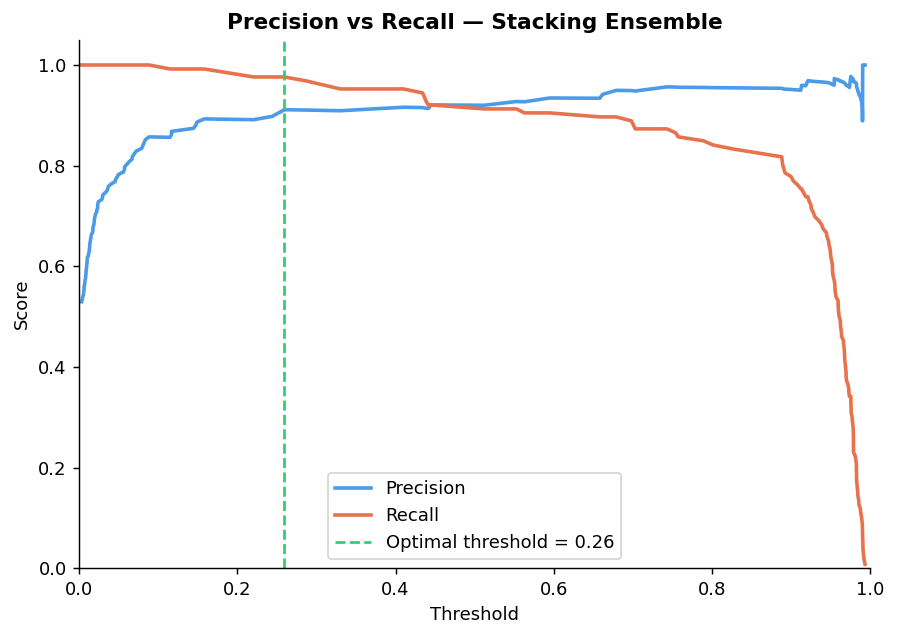

In [12]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ens)

MIN_RECALL = 0.95   # prioritize catching patients (more important than precision)
best_thresh, best_f1, best_prec = 0.5, 0.0, 0.0

for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
    if r >= MIN_RECALL:   # changed condition
        f1 = 2 * p * r / (p + r + 1e-9)
        if f1 > best_f1:
            best_f1, best_thresh, best_prec = f1, t, p

y_pred_ens_opt = (y_prob_ens >= best_thresh).astype(int)

print(f"Optimal threshold (recall ≥ {MIN_RECALL}): {best_thresh:.3f}")
print(f"\n--- Default (0.50) vs Optimised threshold ---")
print(f"  Default  →  Recall: {recall_score(y_test, y_pred_ens):.4f}  "
      f"Precision: {precision_score(y_test, y_pred_ens):.4f}  "
      f"F1: {f1_score(y_test, y_pred_ens):.4f}  "
      f"AUC: {roc_auc_score(y_test, y_prob_ens):.4f}")
print(f"  Optimised→  Recall: {recall_score(y_test, y_pred_ens_opt):.4f}  "
      f"Precision: {precision_score(y_test, y_pred_ens_opt):.4f}  "
      f"F1: {f1_score(y_test, y_pred_ens_opt):.4f}  "
      f"AUC: {roc_auc_score(y_test, y_prob_ens):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precisions[:-1], label="Precision", color=PALETTE["xgb"],  lw=2)
ax.plot(thresholds, recalls[:-1],    label="Recall",    color=PALETTE["svc"],  lw=2)
ax.axvline(best_thresh, color=PALETTE["ensemble"], linestyle="--",
           label=f"Optimal threshold = {best_thresh:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Precision vs Recall — Stacking Ensemble", fontsize=12, fontweight="bold")
ax.legend(); ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("threshold_optimisation.png", bbox_inches="tight")
plt.show()

## 10-Fold Cross-Validation — Report This in Your Paper

In [13]:
print("[CV] 10-Fold Stratified Cross-Validation on full dataset ...")
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

ensemble_cv = StackingClassifier(
    estimators=[
        ("svc", SVC(kernel="rbf",
                    C=best_svc_params["C"],
                    gamma=best_svc_params["gamma"],
                    probability=True,
                    random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(**best_xgb_params)),
    ],
    final_estimator = xgb.XGBClassifier(**best_meta_params),
    cv              = 10,
    stack_method    = "predict_proba",
    passthrough     = True,
    n_jobs          = -1,
)

auc_scores = cross_val_score(ensemble_cv, X, y, cv=cv10, scoring="roc_auc")
f1_scores  = cross_val_score(ensemble_cv, X, y, cv=cv10, scoring="f1")
acc_scores = cross_val_score(ensemble_cv, X, y, cv=cv10, scoring="accuracy")
rec_scores = cross_val_score(ensemble_cv, X, y, cv=cv10, scoring="recall")

print("\n" + "=" * 65)
print("  10-FOLD CV RESULTS  (report these in your paper)")
print("=" * 65)
print(f"  AUC-ROC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
print(f"  Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"  F1-Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"  Recall   : {rec_scores.mean():.4f} ± {rec_scores.std():.4f}")
print("=" * 65)

[CV] 10-Fold Stratified Cross-Validation on full dataset ...

  10-FOLD CV RESULTS  (report these in your paper)
  AUC-ROC  : 0.9778 ± 0.0063
  Accuracy : 0.9429 ± 0.0187
  F1-Score : 0.9468 ± 0.0176
  Recall   : 0.9634 ± 0.0215


## Evaluation — All Three Models

In [14]:
def get_metrics(y_true, y_pred, y_prob, label):
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score (y_true, y_pred),                  4),
        "Recall*"  : round(recall_score   (y_true, y_pred),                  4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score       (y_true, y_pred),                  4),
        "AUC-ROC"  : round(roc_auc_score  (y_true, y_prob),                  4),
    }

rows = [
    get_metrics(y_test, y_pred_svc,     y_prob_svc, "SVC (Optuna-tuned)"),
    get_metrics(y_test, y_pred_xgb,     y_prob_xgb, "XGBoost-Optuna"),
    get_metrics(y_test, y_pred_ens,     y_prob_ens, "Stacking (default thresh 0.50)"),
    get_metrics(y_test, y_pred_ens_opt, y_prob_ens, f"Stacking (opt. thresh {best_thresh:.2f})"),
]
results_df = pd.DataFrame(rows).set_index("Model")

print("=" * 70)
print("  MODEL COMPARISON TABLE")
print("  (* Recall = most critical metric for medical screening)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

  MODEL COMPARISON TABLE
  (* Recall = most critical metric for medical screening)
                                Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                                          
SVC (Optuna-tuned)                0.8908   0.9048     0.8906    0.8976   0.9432
XGBoost-Optuna                    0.9244   0.9286     0.9286    0.9286   0.9710
Stacking (default thresh 0.50)    0.9118   0.9127     0.9200    0.9163   0.9706
Stacking (opt. thresh 0.26)       0.9370   0.9762     0.9111    0.9425   0.9706


### Confusion Matrices

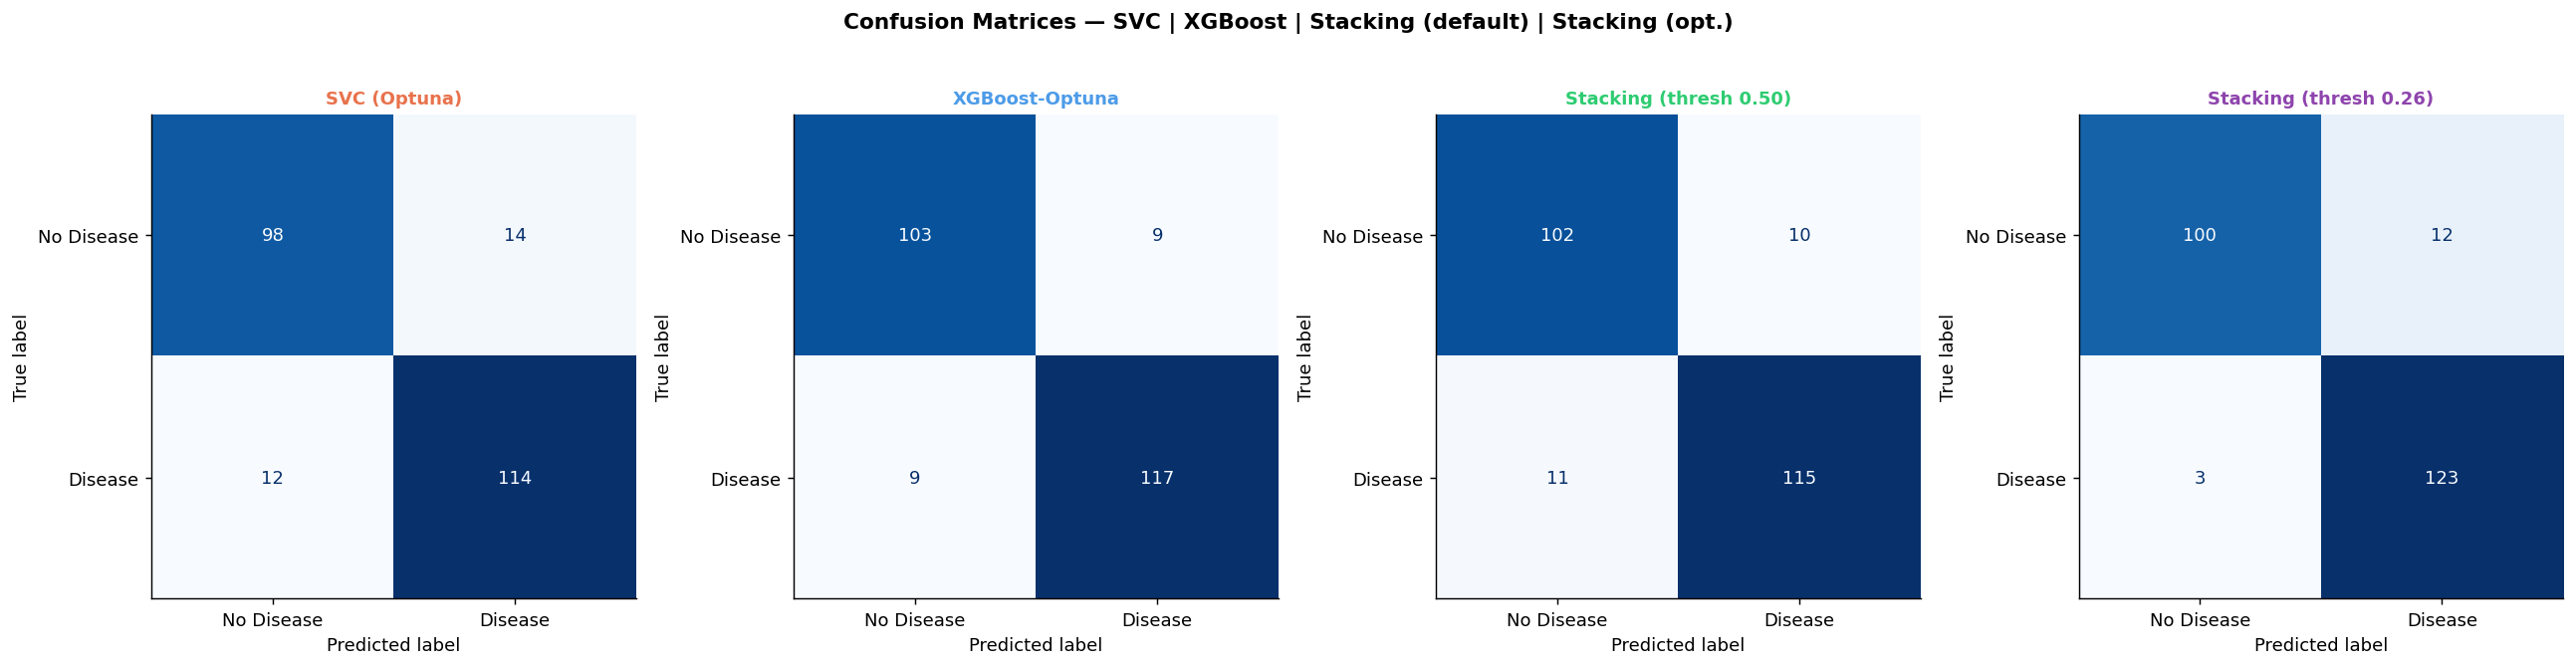

[OK] Saved: svc_xgb_stacking_confusion_matrices.png


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrices — SVC | XGBoost | Stacking (default) | Stacking (opt.)",
             fontsize=12, fontweight="bold", y=1.02)

pairs = [
    (y_pred_svc,     "SVC (Optuna)",              PALETTE["svc"]),
    (y_pred_xgb,     "XGBoost-Optuna",             PALETTE["xgb"]),
    (y_pred_ens,     "Stacking (thresh 0.50)",      PALETTE["ensemble"]),
    (y_pred_ens_opt, f"Stacking (thresh {best_thresh:.2f})", "#8e44ad"),
]

for ax, (y_pred, label, color) in zip(axes, pairs):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(label, fontsize=10, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("svc_xgb_stacking_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_confusion_matrices.png")

### ROC Curves

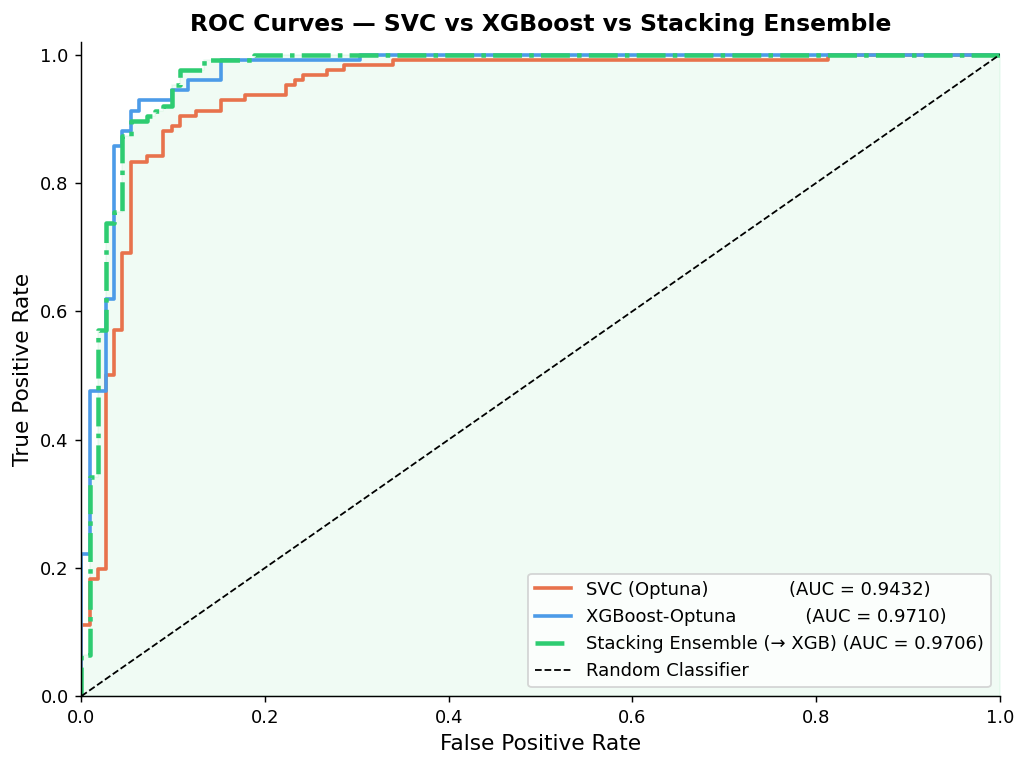

[OK] Saved: svc_xgb_stacking_roc.png


In [16]:
fpr_s, tpr_s, _ = roc_curve(y_test, y_prob_svc)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)
fpr_e, tpr_e, _ = roc_curve(y_test, y_prob_ens)

auc_s = roc_auc_score(y_test, y_prob_svc)
auc_x = roc_auc_score(y_test, y_prob_xgb)
auc_e = roc_auc_score(y_test, y_prob_ens)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_s, tpr_s, color=PALETTE["svc"],     lw=2,   label=f"SVC (Optuna)              (AUC = {auc_s:.4f})")
ax.plot(fpr_x, tpr_x, color=PALETTE["xgb"],     lw=2,   label=f"XGBoost-Optuna            (AUC = {auc_x:.4f})")
ax.plot(fpr_e, tpr_e, color=PALETTE["ensemble"], lw=2.5, label=f"Stacking Ensemble (→ XGB) (AUC = {auc_e:.4f})",
        linestyle="-.")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.fill_between(fpr_e, tpr_e, alpha=0.07, color=PALETTE["ensemble"])

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("ROC Curves — SVC vs XGBoost vs Stacking Ensemble",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("svc_xgb_stacking_roc.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_roc.png")

### Accuracy Comparison Bar Chart

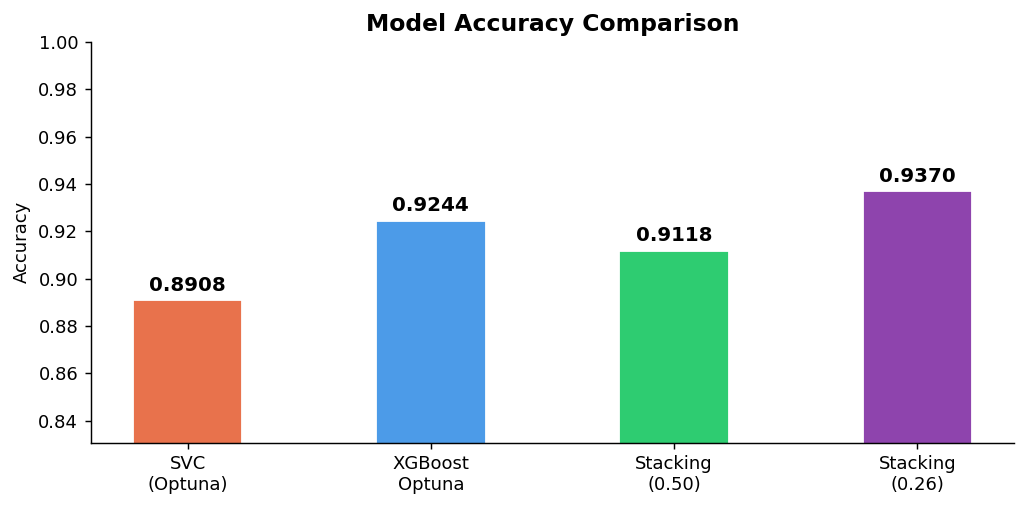

[OK] Saved: svc_xgb_stacking_accuracy.png


In [17]:
comp = {
    "SVC\n(Optuna)"     : accuracy_score(y_test, y_pred_svc),
    "XGBoost\nOptuna"   : accuracy_score(y_test, y_pred_xgb),
    "Stacking\n(0.50)"  : accuracy_score(y_test, y_pred_ens),
    f"Stacking\n({best_thresh:.2f})": accuracy_score(y_test, y_pred_ens_opt),
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    comp.keys(), comp.values(),
    color=[PALETTE["svc"], PALETTE["xgb"], PALETTE["ensemble"], "#8e44ad"],
    width=0.45, edgecolor="white"
)
ax.set_ylabel("Accuracy")
ax.set_ylim(max(0.0, min(comp.values()) - 0.06), 1.0)
ax.set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")

for bar, val in zip(bars, comp.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("svc_xgb_stacking_accuracy.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_accuracy.png")

## SHAP Explainability — XGBoost Base Learner

SHAP explains which features drive predictions in the XGBoost base model.
Critical for medical ML papers — reviewers and clinicians expect explainability.

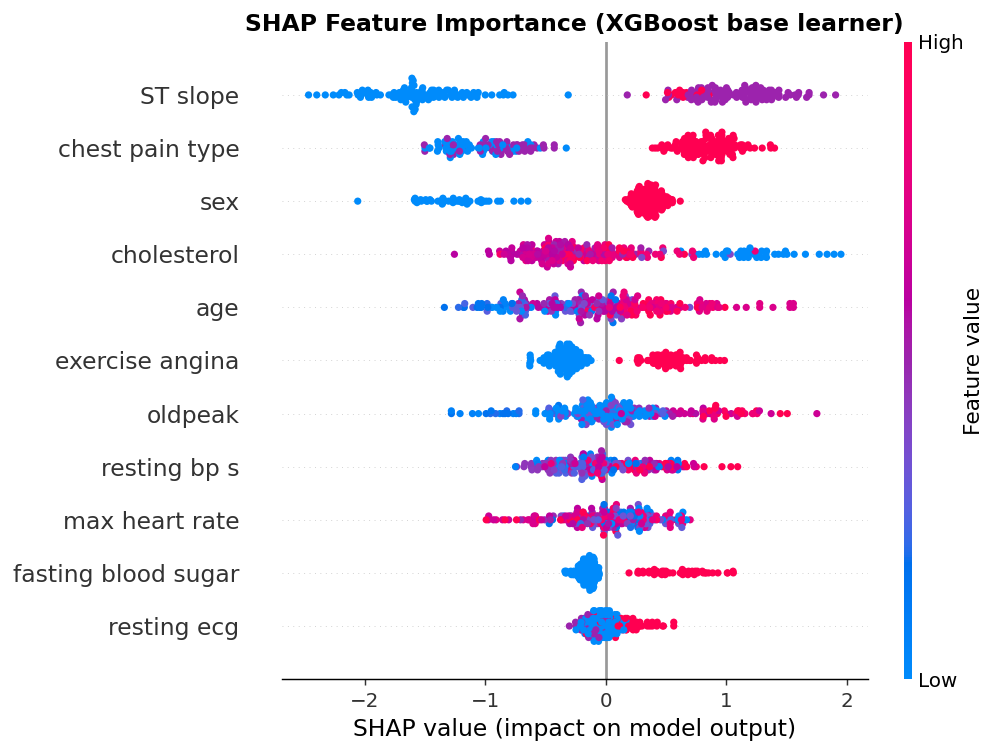

[OK] Saved: svc_xgb_stacking_shap_summary.png


In [18]:
xgb_from_stack = ensemble.named_estimators_["xgb"]
explainer      = shap.TreeExplainer(xgb_from_stack)
shap_values    = explainer.shap_values(X_test_proc)

plt.figure()
shap.summary_plot(shap_values, X_test_proc, feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP Feature Importance (XGBoost base learner)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("svc_xgb_stacking_shap_summary.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_shap_summary.png")

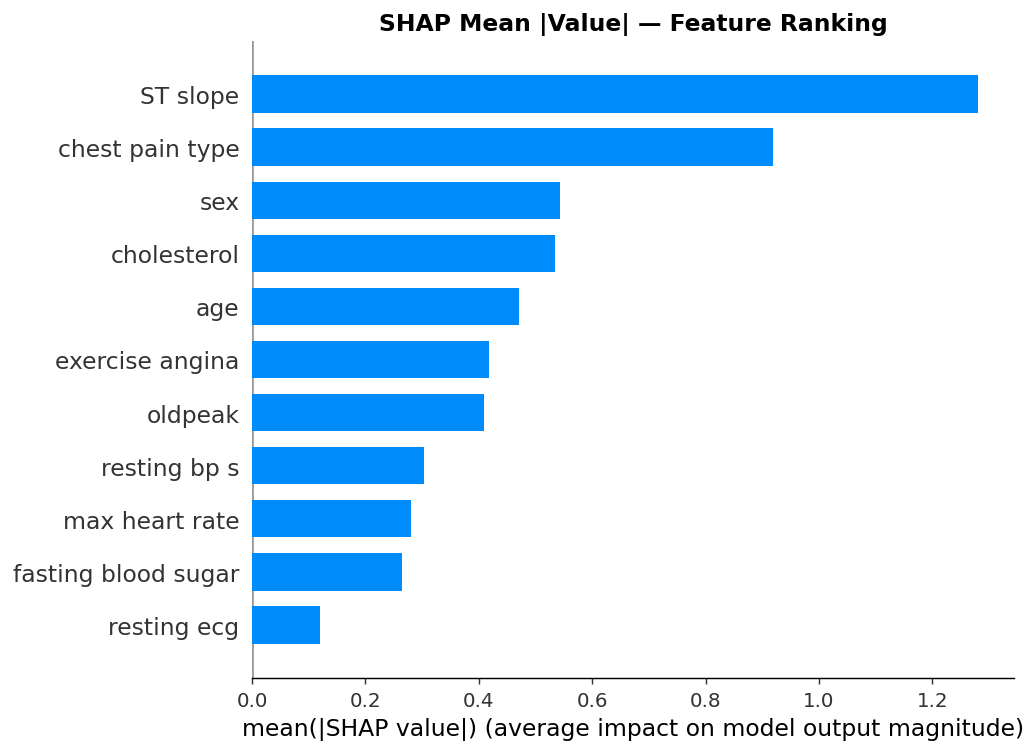

[OK] Saved: svc_xgb_stacking_shap_bar.png


In [19]:
plt.figure()
shap.summary_plot(shap_values, X_test_proc, feature_names=FEATURE_NAMES,
                  plot_type="bar", show=False)
plt.title("SHAP Mean |Value| — Feature Ranking", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("svc_xgb_stacking_shap_bar.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_shap_bar.png")

### XGBoost Native Feature Importance

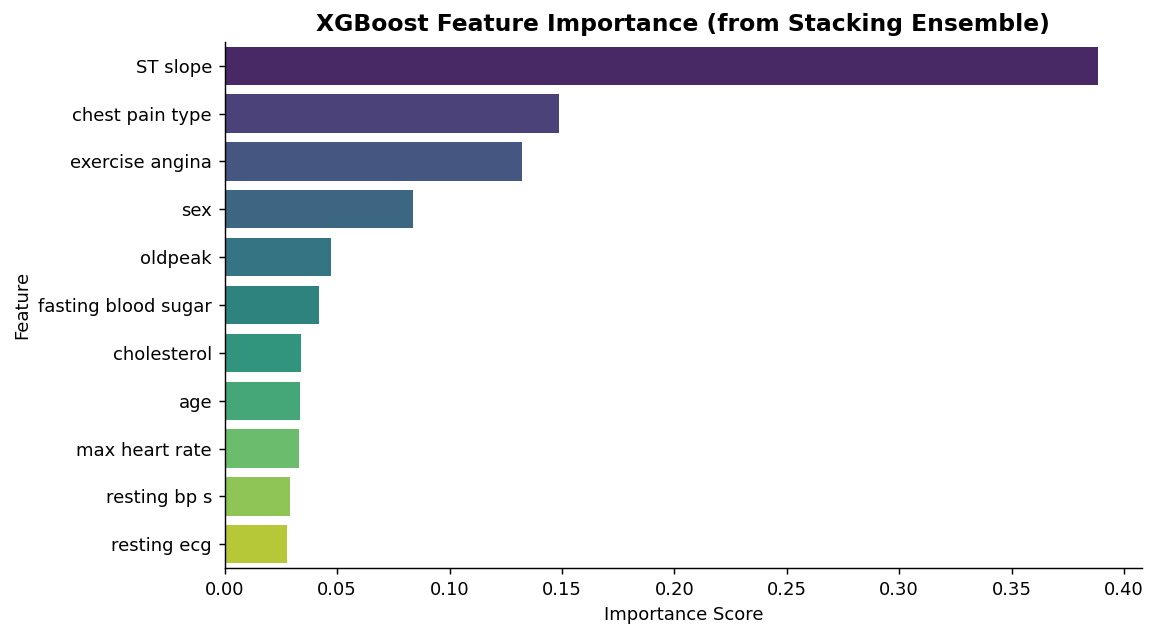

[OK] Saved: svc_xgb_stacking_feature_importance.png


In [20]:
importances = xgb_from_stack.feature_importances_
feat_df = (
    pd.DataFrame({"feature": FEATURE_NAMES, "importance": importances})
    .sort_values("importance", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis", ax=ax)
ax.set_title("XGBoost Feature Importance (from Stacking Ensemble)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("svc_xgb_stacking_feature_importance.png", bbox_inches="tight")
plt.show()
print("[OK] Saved: svc_xgb_stacking_feature_importance.png")

## Full Classification Report — Stacking Ensemble (Optimised Threshold)

In [21]:
print("=" * 65)
print("  STACKING ENSEMBLE v2 — Full Classification Report")
print(f"  (SVC-Optuna + XGBoost-Optuna → XGB Meta-Learner)")
print(f"  (Optimised threshold: {best_thresh:.2f})")
print("=" * 65)
print(classification_report(y_test, y_pred_ens_opt,
                             target_names=["No Disease (0)", "Heart Disease (1)"]))
print("=" * 65)
print("\n  Saved artefacts:")
for f in [
    "threshold_optimisation.png",
    "svc_xgb_stacking_confusion_matrices.png",
    "svc_xgb_stacking_roc.png",
    "svc_xgb_stacking_accuracy.png",
    "svc_xgb_stacking_shap_summary.png",
    "svc_xgb_stacking_shap_bar.png",
    "svc_xgb_stacking_feature_importance.png",
]:
    print(f"    * {f}")
print("=" * 65)

  STACKING ENSEMBLE v2 — Full Classification Report
  (SVC-Optuna + XGBoost-Optuna → XGB Meta-Learner)
  (Optimised threshold: 0.26)
                   precision    recall  f1-score   support

   No Disease (0)       0.97      0.89      0.93       112
Heart Disease (1)       0.91      0.98      0.94       126

         accuracy                           0.94       238
        macro avg       0.94      0.93      0.94       238
     weighted avg       0.94      0.94      0.94       238


  Saved artefacts:
    * threshold_optimisation.png
    * svc_xgb_stacking_confusion_matrices.png
    * svc_xgb_stacking_roc.png
    * svc_xgb_stacking_accuracy.png
    * svc_xgb_stacking_shap_summary.png
    * svc_xgb_stacking_shap_bar.png
    * svc_xgb_stacking_feature_importance.png
